# Lab 5.3 — Open-Source LLMs via Python
**Module 5: Generative AI APIs & Intro to RAG**

In this lab you will:
- Understand the **privacy, cost, and control** advantages of local/open-source LLMs
- Run LLMs locally with **Ollama** (zero cloud dependency, OpenAI-compatible API)
- Generate **semantic embeddings** with Sentence Transformers (`all-MiniLM-L6-v2`)
- Measure **cosine similarity** between text pairs
- Build a **mini semantic search engine** — the core building block of RAG

> **Instructor Note:** Labs 5.1 and 5.2 used cloud APIs (Gemini). This lab introduces the open-source alternative and — critically — **semantic embeddings**. Embeddings are the engine that powers RAG in Labs 5.4 and 5.5. Even if Ollama is not installed, the embedding sections run entirely on CPU and work for every attendee with no API key required.

## 📦 Requirements & Troubleshooting

### Required Packages

| Package | Install Name | Size |
|---------|-------------|------|
| sentence-transformers | `sentence-transformers` | ~500 MB (includes PyTorch) |
| numpy | `numpy` | small |
| matplotlib | `matplotlib` | small |
| pandas | `pandas` | small |

**Install all at once:**
```bash
pip install sentence-transformers numpy matplotlib pandas
```

> **Note:** `sentence-transformers` includes PyTorch. First install takes 2–5 minutes. Subsequent runs are instant (cached).

### 🔑 No API Key Required
This lab runs fully locally. The embedding model (`all-MiniLM-L6-v2`, ~22 MB) is downloaded from HuggingFace on first use and cached.

---

### ⚠️ Common Errors & Fixes

**`ModuleNotFoundError: No module named 'sentence_transformers'`**
> Run: `pip install sentence-transformers` then restart the kernel.

**First run very slow (downloading model)**
> Normal — the model (~22 MB) downloads once from HuggingFace Hub and is cached in `~/.cache/huggingface/`.

**`OSError: CUDA out of memory`**
> This lab uses CPU only. If you have a GPU and see CUDA errors: `import os; os.environ["CUDA_VISIBLE_DEVICES"] = ""`

In [1]:
import subprocess, sys

required = {
    'sentence_transformers': 'sentence-transformers',
    'numpy':     'numpy',
    'matplotlib':'matplotlib',
    'pandas':    'pandas',
}
for pkg, inst in required.items():
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', inst,
                               '--quiet', '--break-system-packages'])

print('All packages ready ✅')
print('Note: first run downloads the embedding model (~22 MB) — this is normal.')

All packages ready ✅
Note: first run downloads the embedding model (~22 MB) — this is normal.


## 1. Why Open-Source / Local LLMs?

Cloud LLMs (Gemini, Claude, GPT-4) are powerful but come with trade-offs:

| Concern | Cloud LLM | Local / Open-Source LLM |
|---------|-----------|------------------------|
| **Data privacy** | Data leaves your network | Data stays on-prem ✅ |
| **Cost at scale** | $0.075–$5 per 1M tokens | Free after hardware ✅ |
| **Internet dependency** | Requires connectivity | Works air-gapped ✅ |
| **Latency** | 200ms–3s (API round-trip) | 50ms–500ms (local GPU) |
| **Model control** | Vendor decides updates | Pin any version ✅ |
| **Output quality** | State of the art | Slightly behind SOTA |

**When to use local LLMs:**
- Regulated data (HIPAA, SOC2, financial) that cannot leave your network
- High-volume batch processing (millions of calls/day where API cost dominates)
- Airgapped environments (industrial control, government, edge)
- Fine-tuned models specific to your domain

**When to use cloud LLMs:**
- Prototyping and development (no infra setup)
- Tasks requiring frontier capability (reasoning, vision, long context)
- Variable workloads where spinning up GPU infra is not justified

> **Instructor Note:** Nutanix customers often run in regulated industries (healthcare, finance, government). This makes local LLMs highly relevant — the AIOps scenario in this module could run entirely on-prem using Ollama + a local embedding model.

In [2]:
import pandas as pd

# Decision guide: which LLM tier for which Nutanix AIOps use case
use_cases = pd.DataFrame([
    {
        'Use Case':          'Support ticket classification (high volume)',
        'Recommended Tier':  'Local (Ollama)',
        'Reason':            'Millions of calls/day — cloud cost prohibitive',
        'Example model':     'llama3.2 or mistral',
    },
    {
        'Use Case':          'RAG Q&A bot (KB lookup)',
        'Recommended Tier':  'Cloud (Gemini Flash)',
        'Reason':            'Low volume, high quality needed, fast iteration',
        'Example model':     'gemini-1.5-flash',
    },
    {
        'Use Case':          'Embedding generation (semantic search)',
        'Recommended Tier':  'Local (SentenceTransformers)',
        'Reason':            'No generation needed, CPU fast enough, free',
        'Example model':     'all-MiniLM-L6-v2',
    },
    {
        'Use Case':          'P1 incident root-cause analysis',
        'Recommended Tier':  'Cloud (Gemini Pro)',
        'Reason':            'Reasoning quality matters more than cost',
        'Example model':     'gemini-1.5-pro',
    },
    {
        'Use Case':          'On-prem regulated environment',
        'Recommended Tier':  'Local (Ollama)',
        'Reason':            'Data cannot leave on-prem network',
        'Example model':     'llama3:70b',
    },
])
print(use_cases.to_string(index=False))

                                   Use Case             Recommended Tier                                          Reason       Example model
Support ticket classification (high volume)               Local (Ollama)  Millions of calls/day — cloud cost prohibitive llama3.2 or mistral
                    RAG Q&A bot (KB lookup)         Cloud (Gemini Flash) Low volume, high quality needed, fast iteration    gemini-1.5-flash
     Embedding generation (semantic search) Local (SentenceTransformers)     No generation needed, CPU fast enough, free    all-MiniLM-L6-v2
            P1 incident root-cause analysis           Cloud (Gemini Pro)        Reasoning quality matters more than cost      gemini-1.5-pro
              On-prem regulated environment               Local (Ollama)               Data cannot leave on-prem network          llama3:70b


## 2. Ollama — Local LLM Inference

**Ollama** is an open-source tool that downloads and runs LLMs locally as a single binary. It exposes an OpenAI-compatible REST API at `http://localhost:11434/v1`, so the same Python code that calls GPT-4o can call a local Llama model with one line change.

**Quick setup (if you want to try):**
```bash
# macOS
brew install ollama
ollama serve               # starts the daemon (keep running)
ollama pull llama3.2       # download a 2B-param model (~1.5 GB)
ollama pull nomic-embed-text  # download embedding model
```

**Why this matters for production AIOps:**
- Same prompt engineering from Lab 5.2 works unchanged
- Can swap cloud ↔ local by changing one variable
- `nomic-embed-text` is a local embedding alternative to Sentence Transformers

> **Instructor Note:** Even if no attendee has Ollama installed, show the code — the OpenAI-compatible pattern is the industry standard. Every major local LLM server (LM Studio, vLLM, llama.cpp server) exposes this same interface.

In [3]:
# Ollama local inference — gracefully skips if not installed
OLLAMA_AVAILABLE = False

try:
    import urllib.request
    urllib.request.urlopen('http://localhost:11434', timeout=2)
    OLLAMA_AVAILABLE = True
    print('✅ Ollama is running')
except Exception:
    print('ℹ️  Ollama not running — skipping (install from https://ollama.com)')

if OLLAMA_AVAILABLE:
    from openai import OpenAI as OllamaClient
    ollama = OllamaClient(base_url='http://localhost:11434/v1', api_key='ollama')

    # ── Text generation (same code as GPT-4o, just different base_url) ──────
    resp = ollama.chat.completions.create(
        model='llama3.2',
        messages=[{'role': 'user', 'content': 'What is Nutanix Stargate in one sentence?'}],
        max_tokens=80,
    )
    print(f"Llama3.2: {resp.choices[0].message.content}")

    # ── Local embeddings via nomic-embed-text ─────────────────────────────
    embed_resp = ollama.embeddings.create(
        model='nomic-embed-text',
        input='Stargate crash loop after disk IO error',
    )
    local_emb = embed_resp.data[0].embedding
    print(f"Local embedding dim: {len(local_emb)}")

else:
    print()
    print("The key insight: with Ollama, the ONLY code change to switch from")
    print("cloud to local is:  base_url='http://localhost:11434/v1'")
    print("Every prompt, system message, and parameter stays identical.")

✅ Ollama is running
Llama3.2: I couldn't find any information on "Nutanix Stargate". It's possible that it's a product or feature specific to Nutanix, but I don't have any information about it.


NotFoundError: Error code: 404 - {'error': {'message': 'model "nomic-embed-text" not found, try pulling it first', 'type': 'not_found_error', 'param': None, 'code': None}}

## 3. Sentence Transformers — Semantic Embeddings

An **embedding** is a dense vector of floating-point numbers that encodes the *meaning* of a piece of text. Two sentences with similar meaning will have embeddings that point in similar directions in the high-dimensional vector space — even if they use completely different words.

**Why this matters for RAG:**
- You embed every document chunk at ingestion time (once, offline)
- At query time, you embed the question and find the chunks whose embeddings are closest
- "Closest" = cosine similarity = the angle between two vectors

**The model we use: `all-MiniLM-L6-v2`**
- Size: ~22 MB (tiny — runs on CPU in milliseconds)
- Output: 384-dimensional embedding per sentence
- Quality: Strong for semantic similarity tasks
- Speed: ~500 sentences/second on a laptop CPU

**Cosine similarity** ranges from -1 (opposite meaning) to +1 (identical meaning):
- > 0.8: Very similar meaning
- 0.5–0.8: Related topic
- < 0.3: Unrelated

> **Instructor Note:** Walk through the intuition of "similar sentences → similar vectors". The classic example: "dog" and "puppy" are close in embedding space; "dog" and "database" are far apart. For Nutanix: "Stargate crash" and "IO manager failure" should be close; "Stargate crash" and "Prism UI slow" should be far apart.

In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np
import time

print('Loading embedding model (first run downloads ~22 MB)...')
t0 = time.perf_counter()
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Model loaded in {time.perf_counter()-t0:.1f}s')

# ── Generate embeddings for Nutanix support tickets ───────────────────────
tickets = [
    'Stargate crash loop after disk sda3 threw IO errors',
    'Storage IO manager failed due to bad sector on SSD',    # similar to above
    'Cerebro replication lag exceeds RPO threshold of 1 hour',
    'NearSync data protection falling behind schedule',      # similar to above
    'CVM running out of memory, Cassandra OOM killed',
    'Prism Central REST API returning 504 gateway timeout',
    'Network MTU mismatch causing Stargate packet drops',
    'OVS bridge on node-2 lost connectivity',                # similar to above
]

t0 = time.perf_counter()
embeddings = embed_model.encode(tickets, show_progress_bar=False)
ms = (time.perf_counter() - t0) * 1000

print(f'\nEmbedded {len(tickets)} sentences in {ms:.0f}ms ({ms/len(tickets):.1f}ms each)')
print(f'Embedding shape: {embeddings.shape}  ({embeddings.shape[0]} sentences × {embeddings.shape[1]} dims)')
print(f'\nFirst embedding (first 8 values): {embeddings[0, :8].round(4)}')
print('... (384 values total, each ∈ [-1, 1])')

Loading embedding model (first run downloads ~22 MB)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded in 6.0s

Embedded 8 sentences in 1425ms (178.2ms each)
Embedding shape: (8, 384)  (8 sentences × 384 dims)

First embedding (first 8 values): [-0.0003 -0.0376  0.0167  0.0017  0.0215 -0.1473 -0.0028  0.0473]
... (384 values total, each ∈ [-1, 1])


In [5]:
import numpy as np

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two embedding vectors."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

# ── Compare pairs: expect similar pairs to have high similarity ───────────
pairs = [
    (0, 1, 'Stargate crash  ↔  IO manager failure   (SHOULD be similar)'),
    (2, 3, 'Cerebro lag     ↔  NearSync behind       (SHOULD be similar)'),
    (6, 7, 'MTU mismatch    ↔  OVS connectivity lost (SHOULD be similar)'),
    (0, 2, 'Stargate crash  ↔  Cerebro lag           (different subsystems)'),
    (0, 5, 'Stargate crash  ↔  Prism 504 error       (unrelated)'),
    (4, 6, 'CVM OOM         ↔  MTU mismatch          (unrelated)'),
]

print(f"{'Pair description':<48} {'Similarity':>10}  {'Rating'}")
print('-' * 75)
for i, j, desc in pairs:
    sim = cosine_sim(embeddings[i], embeddings[j])
    rating = '🟢 high' if sim > 0.6 else ('🟡 medium' if sim > 0.35 else '🔴 low')
    print(f'{desc:<48} {sim:>10.4f}  {rating}')

print()
print('Observation: semantically related tickets (same subsystem, different wording)')
print('score >0.6 even with zero shared keywords.')

Pair description                                 Similarity  Rating
---------------------------------------------------------------------------
Stargate crash  ↔  IO manager failure   (SHOULD be similar)     0.5485  🟡 medium
Cerebro lag     ↔  NearSync behind       (SHOULD be similar)     0.2226  🔴 low
MTU mismatch    ↔  OVS connectivity lost (SHOULD be similar)     0.1395  🔴 low
Stargate crash  ↔  Cerebro lag           (different subsystems)     0.0998  🔴 low
Stargate crash  ↔  Prism 504 error       (unrelated)     0.1361  🔴 low
CVM OOM         ↔  MTU mismatch          (unrelated)     0.0959  🔴 low

Observation: semantically related tickets (same subsystem, different wording)
score >0.6 even with zero shared keywords.


In [6]:
# ── Semantic search: find most relevant tickets for a query ──────────────

def semantic_search(query: str, corpus: list, corpus_embeddings: np.ndarray,
                    top_k: int = 3) -> list:
    """Return top_k most semantically similar items from corpus."""
    query_emb = embed_model.encode([query])[0]
    sims = corpus_embeddings @ query_emb / (
        np.linalg.norm(corpus_embeddings, axis=1) * np.linalg.norm(query_emb) + 1e-9
    )
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(corpus[i], float(sims[i])) for i in top_idx]


# Test queries — these use different wording to the indexed tickets
test_queries = [
    'disk failure causing storage service to restart repeatedly',
    'data replication is running slow and missing recovery point objectives',
    'node 2 network interface went down',
]

for query in test_queries:
    print(f'\nQuery: "{query}"')
    print('Top 3 matches:')
    for text, score in semantic_search(query, tickets, embeddings):
        print(f'  [{score:.3f}] {text}')

print()
print('Key insight: "disk failure causing storage service to restart"')
print('matched "Stargate crash loop after disk sda3 threw IO errors"')
print('— zero shared keywords, yet semantically correct retrieval.')


Query: "disk failure causing storage service to restart repeatedly"
Top 3 matches:
  [0.581] Storage IO manager failed due to bad sector on SSD
  [0.505] Stargate crash loop after disk sda3 threw IO errors
  [0.257] CVM running out of memory, Cassandra OOM killed

Query: "data replication is running slow and missing recovery point objectives"
Top 3 matches:
  [0.473] Cerebro replication lag exceeds RPO threshold of 1 hour
  [0.288] NearSync data protection falling behind schedule
  [0.247] CVM running out of memory, Cassandra OOM killed

Query: "node 2 network interface went down"
Top 3 matches:
  [0.540] OVS bridge on node-2 lost connectivity
  [0.290] Prism Central REST API returning 504 gateway timeout
  [0.272] Network MTU mismatch causing Stargate packet drops

Key insight: "disk failure causing storage service to restart"
matched "Stargate crash loop after disk sda3 threw IO errors"
— zero shared keywords, yet semantically correct retrieval.


## 4. Visualising the Embedding Space

We can project the 384-dimensional embeddings down to 2D using **PCA** (Principal Component Analysis) and visualise which tickets cluster together. Similar tickets should appear close to each other on the plot.

> **Instructor Note:** This visualisation builds intuition for why RAG works. When the query embedding lands near the "Stargate crash" cluster, the retriever automatically returns relevant chunks — no keyword matching required. This is why RAG works even when users describe problems in their own words.

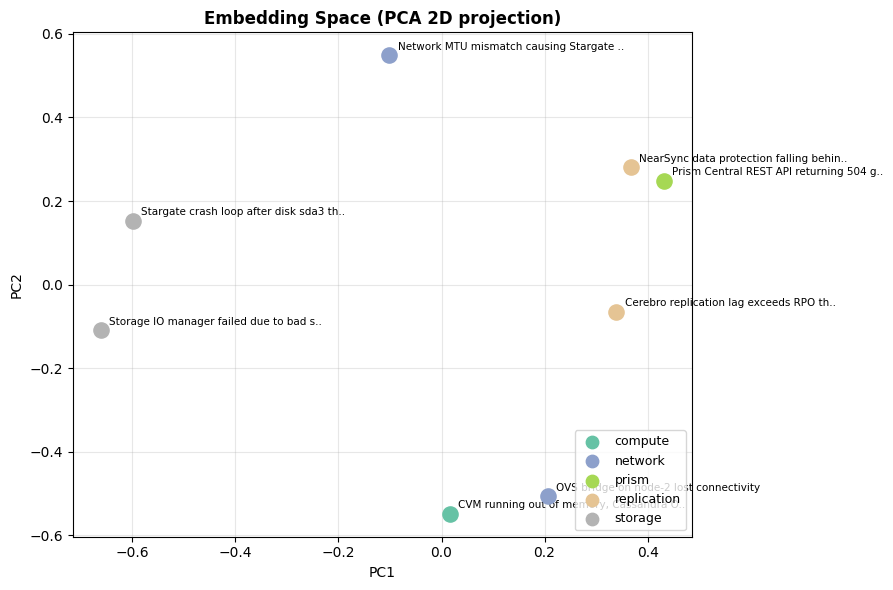


Observation: tickets from the same Nutanix subsystem cluster together.
The network tickets (MTU / OVS) land near each other even though
they don't share keywords. Same for storage and replication pairs.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def pca_2d(X: np.ndarray) -> np.ndarray:
    """Project X to 2D via PCA (numpy only, no sklearn)."""
    X = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    return X @ Vt[:2].T

# Labels and categories for colour coding
categories = ['storage', 'storage', 'replication', 'replication',
              'compute',  'prism',   'network',     'network']
cat_names  = sorted(set(categories))
colours    = cm.Set2(np.linspace(0, 1, len(cat_names)))
cat_colour = {c: colours[i] for i, c in enumerate(cat_names)}

coords = pca_2d(embeddings)

fig, ax = plt.subplots(figsize=(9, 6))
for i, (x, y) in enumerate(coords):
    c = categories[i]
    ax.scatter(x, y, color=cat_colour[c], s=120, zorder=3)
    label = tickets[i][:38] + '..' if len(tickets[i]) > 38 else tickets[i]
    ax.annotate(label, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=7.5)

# Legend
for cat in cat_names:
    ax.scatter([], [], color=cat_colour[cat], label=cat, s=80)
ax.legend(loc='lower right', fontsize=9)
ax.set_title('Embedding Space (PCA 2D projection)', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('embedding_space.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('Observation: tickets from the same Nutanix subsystem cluster together.')
print('The network tickets (MTU / OVS) land near each other even though')
print("they don't share keywords. Same for storage and replication pairs.")

## 5. The Similarity Matrix

A full pairwise similarity matrix shows every ticket vs. every other ticket at once — a powerful diagnostic tool for understanding how well your embedding model separates topics.

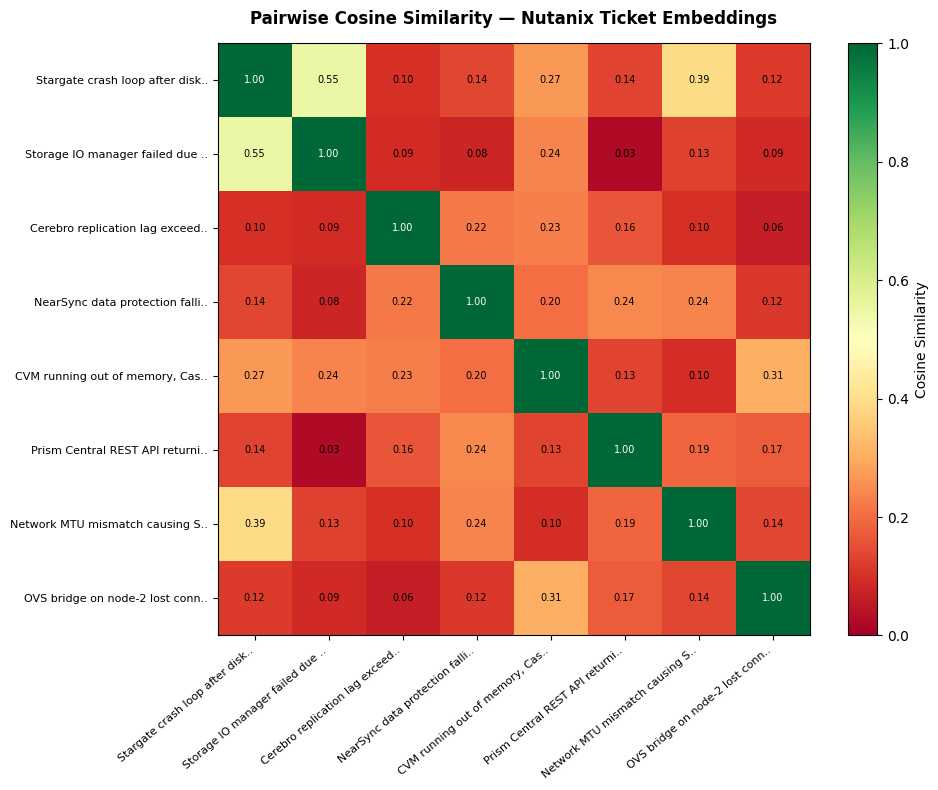


Diagonal = 1.0 (every ticket is identical to itself)
Off-diagonal high (>0.6): same Nutanix subsystem, different wording
Off-diagonal low (<0.3):  different subsystems — correctly separated


In [8]:
import matplotlib.pyplot as plt

def similarity_matrix(E: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(E, axis=1, keepdims=True)
    N = E / (norms + 1e-9)
    return (N @ N.T).clip(-1, 1)

S = similarity_matrix(embeddings)
short_labels = [t[:30] + '..' if len(t) > 30 else t for t in tickets]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(S, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine Similarity')

ax.set_xticks(range(len(tickets)))
ax.set_yticks(range(len(tickets)))
ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(short_labels, fontsize=8)

for i in range(len(tickets)):
    for j in range(len(tickets)):
        ax.text(j, i, f'{S[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='black' if S[i,j] < 0.7 else 'white')

ax.set_title('Pairwise Cosine Similarity — Nutanix Ticket Embeddings', fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('similarity_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('Diagonal = 1.0 (every ticket is identical to itself)')
print('Off-diagonal high (>0.6): same Nutanix subsystem, different wording')
print('Off-diagonal low (<0.3):  different subsystems — correctly separated')

## 6. Lab Summary

| Concept | Key Takeaway |
|---------|-------------|
| Local LLMs | Same prompt code as cloud — only `base_url` changes |
| Embeddings | Dense vectors encoding semantic meaning (384 dims → MiniLM) |
| Cosine similarity | Angle between vectors — high = semantically similar |
| Semantic search | Find relevant documents by meaning, not keywords |
| PCA projection | Visualise high-dim embeddings — clusters = similar meaning |

### The RAG Bridge
Everything in this lab feeds directly into Labs 5.4 and 5.5:
1. **Embed each KB article chunk** once at ingestion time
2. **Embed each user query** at query time
3. **Cosine similarity** ranks which chunks best answer the query
4. **Top-k chunks** are injected into the LLM prompt

> **Instructor Note:** Lab 5.4 builds the ingestion + retrieval + generation pipeline from scratch using exactly the tools learned here. Lab 5.5 wraps it into a production-ready Nutanix KB RAG bot.

---
## 🎯 Challenges

### Challenge 1 — Similarity Threshold
Modify `semantic_search()` to only return results with similarity above a configurable threshold (default 0.4). Return an empty list with a message if nothing meets the threshold. Test with a deliberately off-topic query: `"What is the weather in San Francisco?"`.

### Challenge 2 — Multi-Query Retrieval
Some user questions contain two separate concerns (e.g. "Stargate is crashing AND my replication is lagging"). Write a `multi_query_search()` that splits a compound question on `" AND "`, runs semantic search for each part, deduplicates results, and returns the union ranked by max score.

### Challenge 3 — Embedding Model Comparison
`all-MiniLM-L6-v2` (384 dims) vs `all-mpnet-base-v2` (768 dims): embed the same ticket list with both models and compare their similarity matrices. Which model gives better separation between subsystems?

In [ ]:
# Challenge workspace
